<p align="center">
    <a href="https://predict-idlab.github.io/landmarker">
        <img alt="landmarker" src="https://raw.githubusercontent.com/predict-idlab/landmarker/main/docs/_static/images/logo.svg" width="66%">
    </a>
</p>

# Training and Evaluating Heatmap Regression Model for Landmark Localizatioin on MML (3D)

In this tutorial, we will train and evaluate a heatmap regression model for landmark 
localization on MML. The Mandibular Molar Landmarking (MML) dataset, which consists of 658
annotated CT volumes of the skull. The CT volumes are transformed to a uniform scale of 512 × 512 × 256. Multiple
junior and senior clinicians annotated the CT volumes. It includes 14 mandibular landmarks, specifically, 4 crowns, 8
roots of the second and third mandibular molars, and 2 cups of cuspids. Note that the number of landmarks in a single CT
volume is arbitrary, i.e., some landmarks are absent in the images. We filter out all CT volumes where not all landmarks are present, reducing the dataset size to 399.

We will go through the following steps:
* [Loading the dataset](#Loading-the-dataset)
* [Inspecting the dataset](#Inspecting-the-dataset)
* [Training and initializing the UNet model](#Training-the-model)
* [Evaluating the model](#Evaluating-the-model)

<a target="_blank" href="https://colab.research.google.com/github/predict-idlab/landmarker/examples/3D-example-MML-maskdataset.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

## Setup environment

In [1]:
# !python -c "import landmarker" || pip install landmarker

import sys
import os

import landmarker

## Setup imports and variables

In [2]:
import numpy as np
import torch
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm

In [3]:
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

## Loading the dataset

### Short description of the data and dataset module
The [landmarker](https://github.com/predict-idlab/landmarker) package has several built-in
datasets in the `landmarker.datasets` module, as well as utility classes for building your own
datasets in the `landmarker.data` module. There are three types of datasets: 'LandmarkDataset',
'HeatmapDataset', and 'MaskDataset'. The 'LandmarkDataset' is a dataset of images with landmarks,
the 'HeatmapDataset' is a dataset of images with heatmaps, and the 'MaskDataset' is a dataset of
images with masks (i.e., binary segmentation masks indiciating the location of the landmarks). The 
'HeatmapDataset' and 'MaskDataset' both inherit from the 'LandmarkDataset' class, and thus also 
contain information about the landmarks. The 'MaskDataset' can be constructed from specified image 
and landmarks pairs, or from images and masks pairs, because often that is how the data is
distributed. The 'HeatmapDataset' can be constructed from images and landmarks pairs.

Images can be provided as a list of paths to stored images, or as a a numpy arary, torch tensor, 
list of numpy  arrays or list of torch tensors. Landmarks can be as numpy arrays or torch tensors.
These landmarks can be provided in three different shapes: (1) (N, D) where N is the number of
samples and D is the number of dimensions, (2) (N, C, D) where C is the number of landmark
classes, (3) (N, C, I, D) where I is the number of instances per landmark class, if less than I
instances are provided, the remaining instances are filled with NaNs.

In [4]:
from monai.transforms import (Compose, ScaleIntensityd, RandAffineD)

fn_keys = ('image', )
spatial_transformd = [
    # RandAffineD(
    #     keys=fn_keys,
    #     mode=('bilinear', ),
    #     prob=1,)
]

train_transformd = Compose([
                            ScaleIntensityd(('image', )),  # Scale intensity
                        ] + spatial_transformd)

inference_transformd = Compose([
    ScaleIntensityd(('image', )),
])

In [5]:
from glob import glob

path_data = "data/MML_center_crop_shuffled"

# Warning ensure that lists of paths for volumes, landmarks, and pixel_spacings

# volume paths
volume_paths_train = sorted(glob(f"{path_data}/train/*_volume.npy"))
volume_paths_val = sorted(glob(f"{path_data}/val/*_volume.npy"))
volume_paths_test = sorted(glob(f"{path_data}/test/*_volume.npy"))

# landmark paths and transform to single numpy arrays for each set
landmarks_paths_train = sorted(glob(f"{path_data}/train/*_label.npy"))
landmarks_train = np.stack([np.load(path) for path in landmarks_paths_train])
landmarks_paths_val = sorted(glob(f"{path_data}/val/*_label.npy"))
landmarks_val = np.stack([np.load(path) for path in landmarks_paths_val])
landmarks_paths_test = sorted(glob(f"{path_data}/test/*_label.npy"))
landmarks_test = np.stack([np.load(path) for path in landmarks_paths_test])

# voxel spacing paths and transform to single numpy arrays for each set
spacing_paths_train = sorted(glob(f"{path_data}/train/*_spacing.npy"))
pixel_spacings_train = np.stack([np.load(path) for path in spacing_paths_train])
spacing_paths_val = sorted(glob(f"{path_data}/val/*_spacing.npy"))
pixel_spacings_val = np.stack([np.load(path) for path in spacing_paths_val])
spacing_paths_test = sorted(glob(f"{path_data}/test/*_spacing.npy"))
pixel_spacings_test = np.stack([np.load(path) for path in spacing_paths_test])


In [6]:
dim_img = (128, 128, 64)

In [7]:
from landmarker.data import HeatmapDataset
sigma = 2
gamma = None
ds_train = HeatmapDataset(
    imgs=volume_paths_train,
    landmarks=landmarks_train,
    spatial_dims=3,
    sigma=sigma,
    pixel_spacing=pixel_spacings_train,
    transform=train_transformd,
    store_imgs=False,
    dim_img=dim_img,
    gamma=gamma
)

ds_val = HeatmapDataset(
    imgs=volume_paths_val,
    landmarks=landmarks_val,
    spatial_dims=3,
    sigma=sigma,
    pixel_spacing=pixel_spacings_val,
    transform=inference_transformd,
    store_imgs=False,
    dim_img=dim_img,
    gamma=gamma
)

ds_test = HeatmapDataset(
    imgs=volume_paths_test,
    landmarks=landmarks_test,
    spatial_dims=3,
    sigma=sigma,
    pixel_spacing=pixel_spacings_test,
    transform=inference_transformd,
    store_imgs=False,
    dim_img=dim_img,
    gamma=gamma
)

## Inspecting the dataset

In [8]:
batch = ds_train[0]

In [9]:
# %pip install 'napari[all]'
# %pip install 'ipyvolume'

### Visualize 3D Image + Landmarks

In [10]:
import napari
import numpy as np


viewer = napari.Viewer(ndisplay=3)

viewer.add_image(batch["image"][0])

# Add landmarks (as points layer)
viewer.add_points(
    batch["landmark"],
    size=5,
    face_color="red",
    name="landmarks"
)

napari.run()


ModuleNotFoundError: No module named 'napari'

In [ ]:
import ipyvolume as ipv
import numpy as np

# Show volume
ipv.quickvolshow(batch["image"][0], level=[0.3, 0.6], opacity=0.03)

# Extract xyz coords
z, y, x = batch["landmark"].T

# Plot landmarks
ipv.scatter(x, y, z, color="red", size=5, marker="sphere")

ipv.show()

### Visualize 3D Image + Heatmaps + Landmarks

In [ ]:
import napari

viewer = napari.Viewer(ndisplay=3)

viewer.add_image(batch["image"][0], name="volume")

viewer.add_points(
    batch["landmark"],
    size=2,
    face_color="blue",
    name="landmarks"
)

# Heatmaps as image layers
for c in range(14):
    hm = batch["mask"][c]  # should be float/continuous
    viewer.add_image(
        hm,
        name=f"heatmap_{c}",
        colormap="magma",      # try: "inferno", "viridis", "cyan", ...
        blending="additive",   # good for overlays
        opacity=0.6,
        contrast_limits=(0, 1) # adjust if your heatmaps are not in [0,1]
    )

napari.run()

## Training and initializing the Unet model

### Initializing the model, optimizer and loss function

In [8]:
from monai.networks.nets import FlexibleUNet

model = FlexibleUNet(
                    in_channels=1,
                    out_channels=14, # nb of landmarks
                    backbone="efficientnet-b0",
                    pretrained=True,
                    decoder_channels=[128, 128, 128, 128, 128],
                    spatial_dims=3,
                    norm="batch",
                    act="relu",
                    dropout=0.0,
                    decoder_bias=False,
                    upsample="nontrainable",
                    pre_conv="default",
                    interp_mode="nearest",
                    is_pad=True,
                    ).to(device)
print("Number of learnable parameters: {}".format(
    sum(p.numel() for p in model.parameters() if p.requires_grad)))
lr = 1e-5
batch_size = 1
epochs = 60

optimizer = torch.optim.Adam(
            [
                {"params": model.parameters()},
            ],
            lr=lr,
)


criterion = torch.nn.BCEWithLogitsLoss()

decoder_method = "argmax"

lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5,
                                                          patience=10, cooldown=10)

Number of learnable parameters: 10630738


### Setting the data loaders

In [9]:
train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=4)
test_loader = DataLoader(ds_test, batch_size=batch_size, shuffle=False, num_workers=4)

### Training the model

In [10]:
from landmarker.heatmap.decoder import heatmap_to_coord
from landmarker.metrics import point_error
from torch.nn.functional import sigmoid

def train_epoch(model, train_loader, criterion, optimizer, device):
    running_loss = 0
    model.train()
    for i, batch in enumerate(tqdm(train_loader)):
        images = batch["image"].to(device)
        masks = batch["mask"].to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 10000.0)
        optimizer.step()
        running_loss += loss.item()
    return running_loss / len(train_loader)

def val_epoch(model, val_loader, criterion, device, method="argmax"):
    eval_loss = 0
    eval_mpe = 0
    model.eval()
    with torch.no_grad():
        for i, batch in enumerate(tqdm(val_loader)):
            images = batch["image"].to(device)
            outputs = model(images)
            dim_orig = batch["dim_original"].to(device)
            pixel_spacing = batch["spacing"].to(device)
            padding = batch["padding"].to(device)
            masks = batch["mask"].to(device)
            landmarks = batch["landmark"].to(device)
            loss = criterion(outputs, masks)
            pred_landmarks = heatmap_to_coord(sigmoid(outputs), method=method, spatial_dims=3)
            eval_loss += loss.item()
            eval_mpe += point_error(landmarks, pred_landmarks, images.shape[-3:], dim_orig,
                                    pixel_spacing, padding, reduction="mean")
    return eval_loss / len(val_loader), eval_mpe / len(val_loader)

def train(model, train_loader, val_loader, criterion, optimizer, device, epochs=1000):
    for epoch in tqdm(range(epochs)):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_mpe = val_epoch(model, val_loader, criterion, device)
        print(f"Epoch {epoch+1}/{epochs} - Train loss: {train_loss:.4f} - Val loss: {val_loss:.4f} - Val mpe: {val_mpe:.4f}")
        lr_scheduler.step(val_loss)

In [11]:
train(model, train_loader, val_loader, criterion, optimizer, device,
      epochs=epochs)

  0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/199 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1/60 - Train loss: 0.3126 - Val loss: 0.0943 - Val mpe: 67.2267


  0%|          | 0/199 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 59/60 - Train loss: 0.0003 - Val loss: 0.0005 - Val mpe: 3.0179


  0%|          | 0/199 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 60/60 - Train loss: 0.0003 - Val loss: 0.0005 - Val mpe: 2.8944


In [16]:
torch.save(model.state_dict(), "3D-mml-static-heatmap-unet.pt")

## Evaluating the model

In [17]:
model.load_state_dict(torch.load("3D-mml-static-heatmap-unet.pt", weights_only=True))

<All keys matched successfully>

In [12]:
pred_landmarks_test = []
true_landmarks_test = []
dim_origs_test = []
pixel_spacings_test = []
paddings_test = []
test_mpe = 0
model.eval()
model.to(device)
with torch.no_grad():
    for i, batch in enumerate(tqdm(test_loader)):
        images = batch["image"].to(device)
        outputs = sigmoid(model(images))
        dim_orig = batch["dim_original"].to(device)
        pixel_spacing = batch["spacing"].to(device)
        padding = batch["padding"].to(device)
        landmarks = batch["landmark"].to(device)
        pred_landmark = heatmap_to_coord(outputs, method="argmax", spatial_dims=3)
        test_mpe += point_error(landmarks, pred_landmark, images.shape[-3:], dim_orig,
                                pixel_spacing, padding, reduction="mean")
        pred_landmarks_test.append(pred_landmark.cpu())
        true_landmarks_test.append(landmarks.cpu())
        dim_origs_test.append(dim_orig.cpu())
        pixel_spacings_test.append(pixel_spacing.cpu())
        paddings_test.append(padding.cpu())

pred_landmarks_test = torch.cat(pred_landmarks_test)
true_landmarks_test = torch.cat(true_landmarks_test)
dim_origs_test = torch.cat(dim_origs_test)
pixel_spacings_test = torch.cat(pixel_spacings_test)
paddings_test = torch.cat(paddings_test)

test_mpe /= len(test_loader)

print(f"Test Mean PE: {test_mpe:.4f}")

  0%|          | 0/100 [00:00<?, ?it/s]

Test Mean PE: 3.3666


In [13]:
from landmarker.metrics import sdr

sdr_test = sdr([2.0, 2.5, 3.0, 4.0], true_landmarks=true_landmarks_test, pred_landmarks=pred_landmarks_test,
               dim=dim_img, dim_orig=dim_origs_test.int(), pixel_spacing=pixel_spacings_test, padding=paddings_test)

print("Results on Test Set:")
for key in sdr_test:
    print(f"SDR for {key}mm: {sdr_test[key]:.4f}")

Results on Test Set:
SDR for 2.0mm: 56.2857
SDR for 2.5mm: 70.5714
SDR for 3.0mm: 75.7857
SDR for 4.0mm: 85.0000


In [14]:
from landmarker.visualize import detection_report

print("Test Set")
detection_report(true_landmarks_test, pred_landmarks_test, dim=dim_img, dim_orig=dim_origs_test.int(),
                    pixel_spacing=pixel_spacings_test, padding=paddings_test, class_names=ds_test.class_names,
                    radius=[2.0, 2.5, 3.0, 4.0], digits=2)

Test Set
Detection report:
1# Point-to-point error (PE) statistics:
Class               Mean      Median    Std       Min       Max       
----------------------------------------------------------------------
landmark_0          2.98      1.62      6.74      0.47      67.00     
landmark_1          3.34      1.44      7.40      0.02      54.05     
landmark_2          5.56      1.93      14.21     0.20      80.58     
landmark_3          5.15      2.01      10.13     0.29      56.07     
landmark_4          1.90      1.38      1.71      0.11      9.51      
landmark_5          5.58      2.30      12.93     0.00      70.89     
landmark_6          4.95      2.16      11.55     0.04      66.89     
landmark_7          2.48      1.54      2.67      0.06      18.56     
landmark_8          2.42      1.42      2.76      0.03      15.24     
landmark_9          2.92      1.85      7.00      0.03      70.68     
landmark_10         2.30      1.78      1.78      0.01      9.91      
landmark_

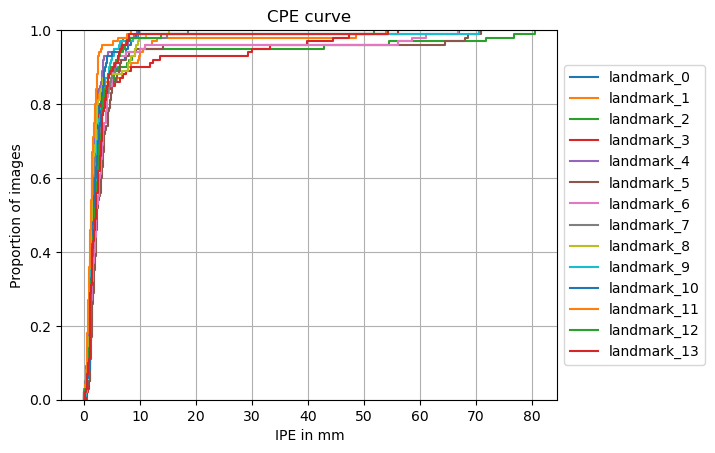

In [15]:
from landmarker.visualize import plot_cpe

plot_cpe(true_landmarks_test, pred_landmarks_test, dim=dim_img, dim_orig=dim_origs_test.int(),
                    pixel_spacing=pixel_spacings_test, padding=paddings_test, class_names=ds_test.class_names,
                    group=False, title="CPE curve", save_path=None,
                    stat='proportion', unit='mm', kind='ecdf')